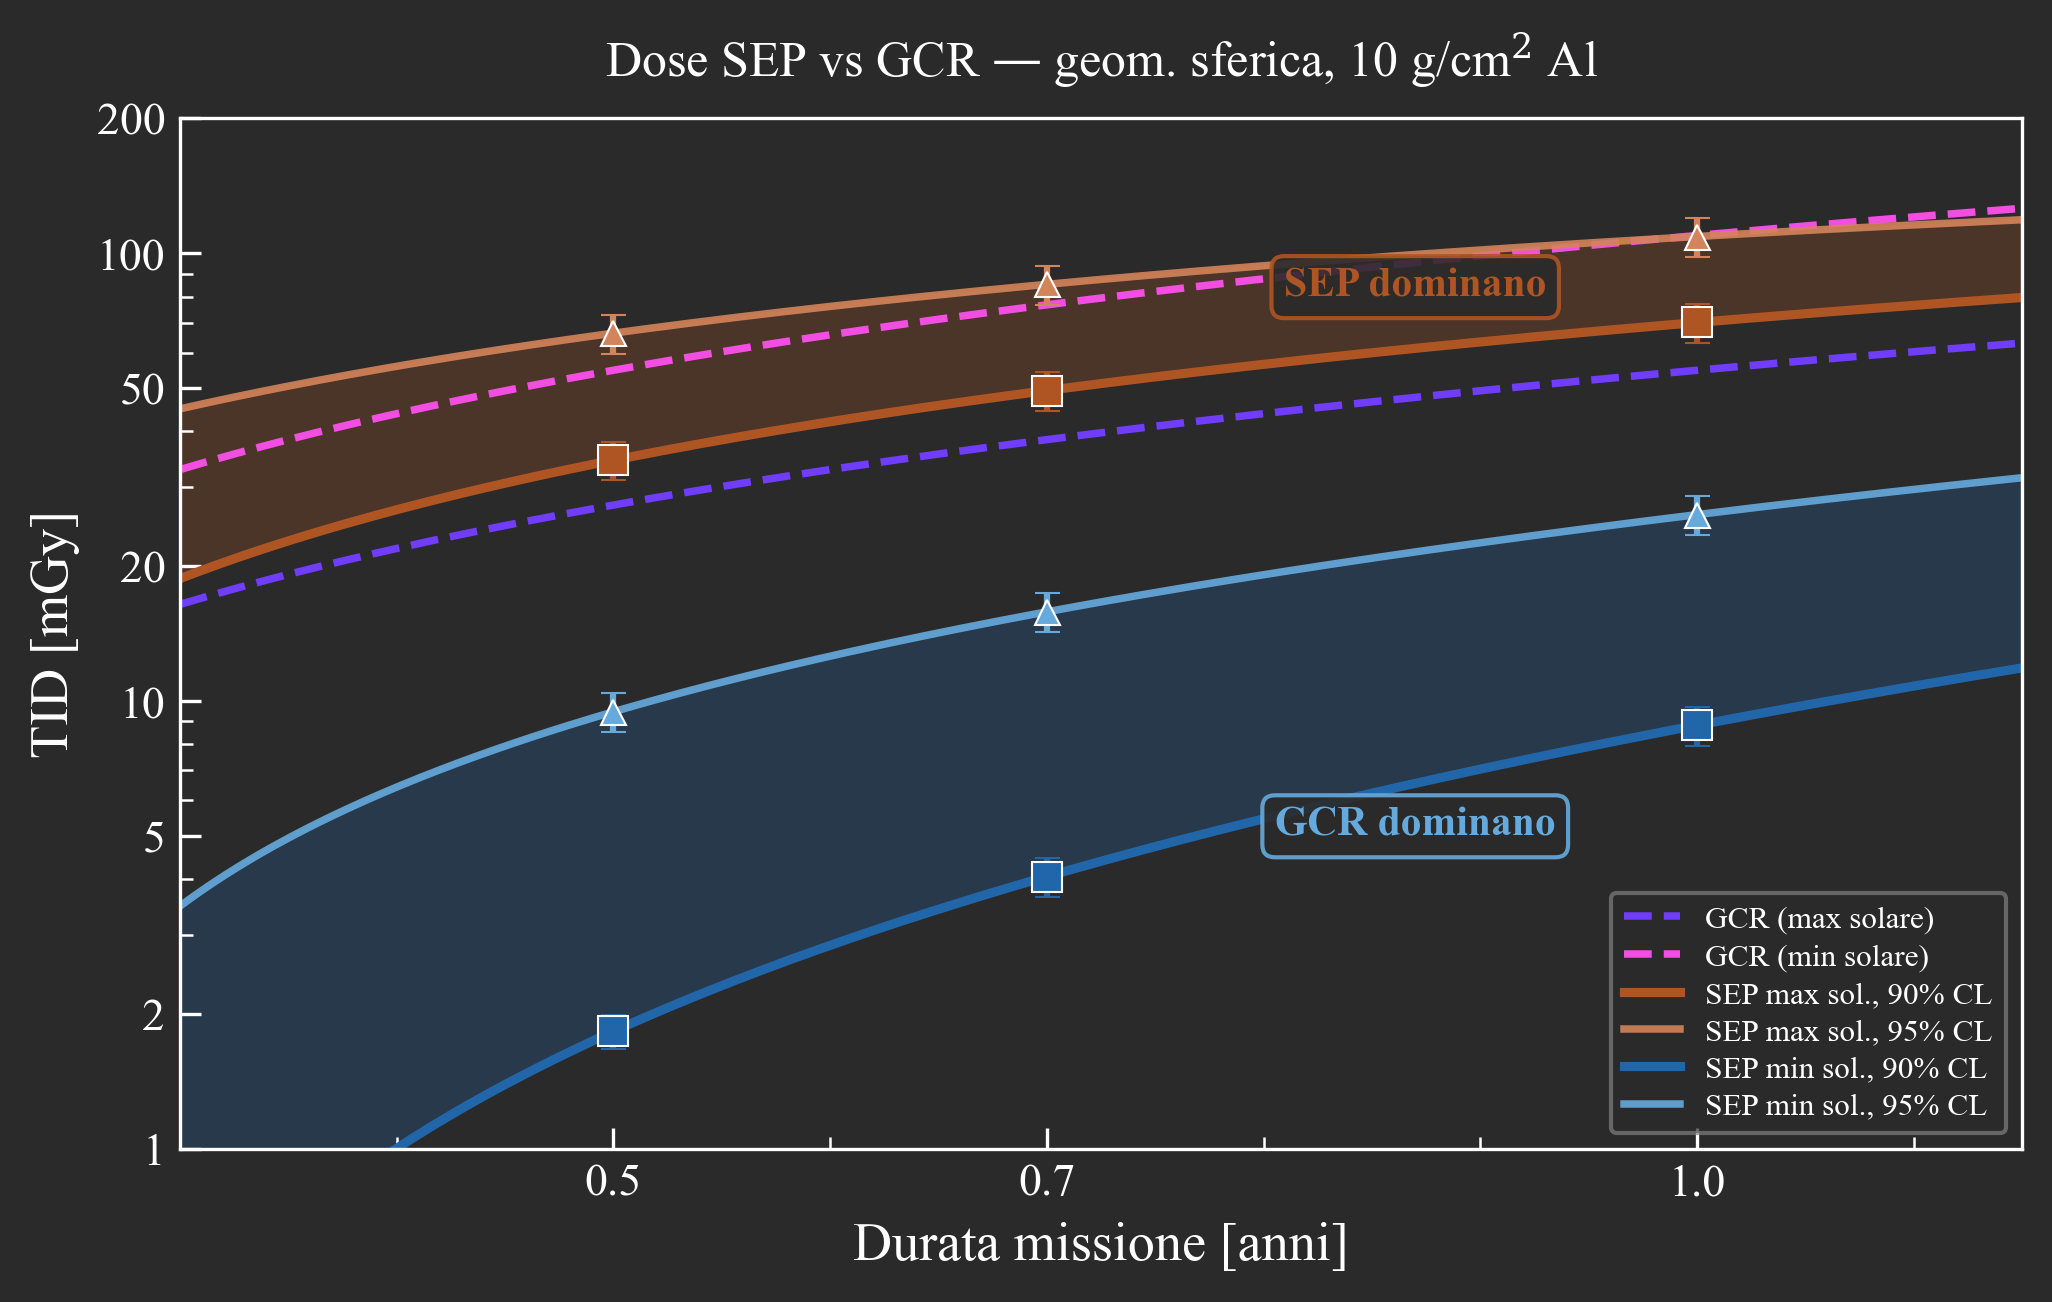

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, FixedLocator, NullFormatter
from scipy.interpolate import interp1d

# --- Thesis rcParams style ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'axes.grid': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

fig, ax = plt.subplots(figsize=(7, 4.5))
fig.patch.set_facecolor('#2a2a2a')
ax.set_facecolor('#2a2a2a')

# --- DATA from thesis (Table 4.1, spherical, 1 AU) ---
durations_data = np.array([0.5, 0.7, 1.0])

# SEP Solar Max
sep_max_90 = np.array([43.4, 62.1, 88.1])
sep_max_90_err = np.array([4.3, 6.2, 8.7])
sep_max_95 = np.array([83.4, 107.2, 137.1])
sep_max_95_err = np.array([8.3, 10.6, 13.6])

# SEP Solar Min
sep_min_90 = np.array([2.3, 5.1, 11.1])
sep_min_90_err = np.array([0.2, 0.5, 1.1])
sep_min_95 = np.array([11.9, 19.9, 32.8])
sep_min_95_err = np.array([1.2, 2.0, 3.3])

# SOLPENCO2 scaling factor (~20.5% reduction)
f_solpenco = 0.795

# Scaled SEP values
sep_max_90_sc = sep_max_90 * f_solpenco
sep_max_90_sc_err = sep_max_90_err * f_solpenco
sep_max_95_sc = sep_max_95 * f_solpenco
sep_max_95_sc_err = sep_max_95_err * f_solpenco

sep_min_90_sc = sep_min_90 * f_solpenco
sep_min_90_sc_err = sep_min_90_err * f_solpenco
sep_min_95_sc = sep_min_95 * f_solpenco
sep_min_95_sc_err = sep_min_95_err * f_solpenco

# GCR dose rates (Si, from thesis Section 5)
gcr_rate_max = 0.15  # mGy/day solar max
gcr_rate_min = 0.30  # mGy/day solar min

# Smooth curves
durations_smooth = np.linspace(0.3, 1.15, 200)
days_smooth = durations_smooth * 365.25

gcr_max = gcr_rate_max * days_smooth
gcr_min = gcr_rate_min * days_smooth

# Interpolations — 1 AU
sep_max_90_f = interp1d(durations_data, sep_max_90, kind='quadratic', fill_value='extrapolate')
sep_max_95_f = interp1d(durations_data, sep_max_95, kind='quadratic', fill_value='extrapolate')
sep_min_90_f = interp1d(durations_data, sep_min_90, kind='quadratic', fill_value='extrapolate')
sep_min_95_f = interp1d(durations_data, sep_min_95, kind='quadratic', fill_value='extrapolate')

# Interpolations — SOLPENCO2 scaled
sep_max_90_sc_f = interp1d(durations_data, sep_max_90_sc, kind='quadratic', fill_value='extrapolate')
sep_max_95_sc_f = interp1d(durations_data, sep_max_95_sc, kind='quadratic', fill_value='extrapolate')
sep_min_90_sc_f = interp1d(durations_data, sep_min_90_sc, kind='quadratic', fill_value='extrapolate')
sep_min_95_sc_f = interp1d(durations_data, sep_min_95_sc, kind='quadratic', fill_value='extrapolate')

s_max_90 = sep_max_90_f(durations_smooth)
s_max_95 = sep_max_95_f(durations_smooth)
s_min_90 = sep_min_90_f(durations_smooth)
s_min_95 = sep_min_95_f(durations_smooth)

s_max_90_sc = sep_max_90_sc_f(durations_smooth)
s_max_95_sc = sep_max_95_sc_f(durations_smooth)
s_min_90_sc = sep_min_90_sc_f(durations_smooth)
s_min_95_sc = sep_min_95_sc_f(durations_smooth)

# --- Colors ---
terracotta = '#AF5523'
terracotta_light = '#D4845A'
blue_dark = '#2266AA'
blue_light = '#66AADD'
gcr_color_max = "#6F3DFB"
gcr_color_min = "#F24EE2"

# ============================================================
# PLOT
# ============================================================

# --- GCR ---

ax.plot(durations_smooth, gcr_max, '--', color=gcr_color_max, linewidth=1.8, label='GCR (max solare)')
ax.plot(durations_smooth, gcr_min, '--', color=gcr_color_min, linewidth=1.8, label='GCR (min solare)')



# --- SEP SOLPENCO2-scaled (main curves) ---
ax.fill_between(durations_smooth, s_max_90_sc, s_max_95_sc, alpha=0.25, color=terracotta)
ax.plot(durations_smooth, s_max_90_sc, '-', color=terracotta, linewidth=2.2, 
        label='SEP max sol., 90% CL')
ax.plot(durations_smooth, s_max_95_sc, '-', color=terracotta_light, linewidth=1.8, alpha=0.9,
        label='SEP max sol., 95% CL')

ax.fill_between(durations_smooth, s_min_90_sc, s_min_95_sc, alpha=0.25, color=blue_dark)
ax.plot(durations_smooth, s_min_90_sc, '-', color=blue_dark, linewidth=2.2,
        label='SEP min sol., 90% CL ')
ax.plot(durations_smooth, s_min_95_sc, '-', color=blue_light, linewidth=1.8, alpha=0.9,
        label='SEP min sol., 95% CL')

# Data points — SOLPENCO2 scaled
ax.errorbar(durations_data, sep_max_90_sc, yerr=sep_max_90_sc_err, fmt='s', color=terracotta,
            markersize=7, markeredgecolor='white', markeredgewidth=0.5, capsize=3, zorder=5)
ax.errorbar(durations_data, sep_max_95_sc, yerr=sep_max_95_sc_err, fmt='^', color=terracotta_light,
            markersize=6, markeredgecolor='white', markeredgewidth=0.5, capsize=3, zorder=5)
ax.errorbar(durations_data, sep_min_90_sc, yerr=sep_min_90_sc_err, fmt='s', color=blue_dark,
            markersize=7, markeredgecolor='white', markeredgewidth=0.5, capsize=3, zorder=5)
ax.errorbar(durations_data, sep_min_95_sc, yerr=sep_min_95_sc_err, fmt='^', color=blue_light,
            markersize=6, markeredgecolor='white', markeredgewidth=0.5, capsize=3, zorder=5)



# --- Annotations ---
ax.annotate('SEP dominano', xy=(0.87, 80), fontsize=10, color=terracotta,
            fontweight='bold', ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#2a2a2a', edgecolor=terracotta, alpha=0.9))

ax.annotate('GCR dominano', xy=(0.87, 5), fontsize=10, color=blue_light,
            fontweight='bold', ha='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#2a2a2a', edgecolor=blue_light, alpha=0.9))






# --- Axes ---
ax.set_yscale('log')
ax.set_xlim(0.3, 1.15)
ax.set_ylim(1, 200)
ax.set_xlabel('Durata missione [anni]', color='white')
ax.set_ylabel('TID [mGy]', color='white')
ax.set_title('Dose SEP vs GCR — geom. sferica, 10 g/cm$^2$ Al', 
             color='white', fontsize=12, pad=10)

ax.set_xticks([0.5, 0.7, 1.0])
ax.set_xticklabels(['0.5', '0.7', '1.0'])
ax.tick_params(colors='white', which='both')
ax.xaxis.set_minor_locator(AutoMinorLocator(2))

ax.yaxis.set_major_locator(FixedLocator([1, 2, 5, 10, 20, 50, 100, 200]))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:g}'))
ax.yaxis.set_minor_formatter(NullFormatter())

for spine in ax.spines.values():
    spine.set_color('white')

# Legend — compact
legend = ax.legend(loc='lower right', fontsize=7.5, framealpha=0.7,
                   facecolor='#2a2a2a', edgecolor='gray', ncol=1,
                   handlelength=1.8, borderpad=0.4, labelspacing=0.3)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.savefig('sep_vs_gcr_dose_v2.png', dpi=300, facecolor='#2a2a2a',
            bbox_inches='tight', transparent=False)
plt.savefig('sep_vs_gcr_dose_v2.pdf', facecolor='#2a2a2a',
            bbox_inches='tight', transparent=False)
plt.show()

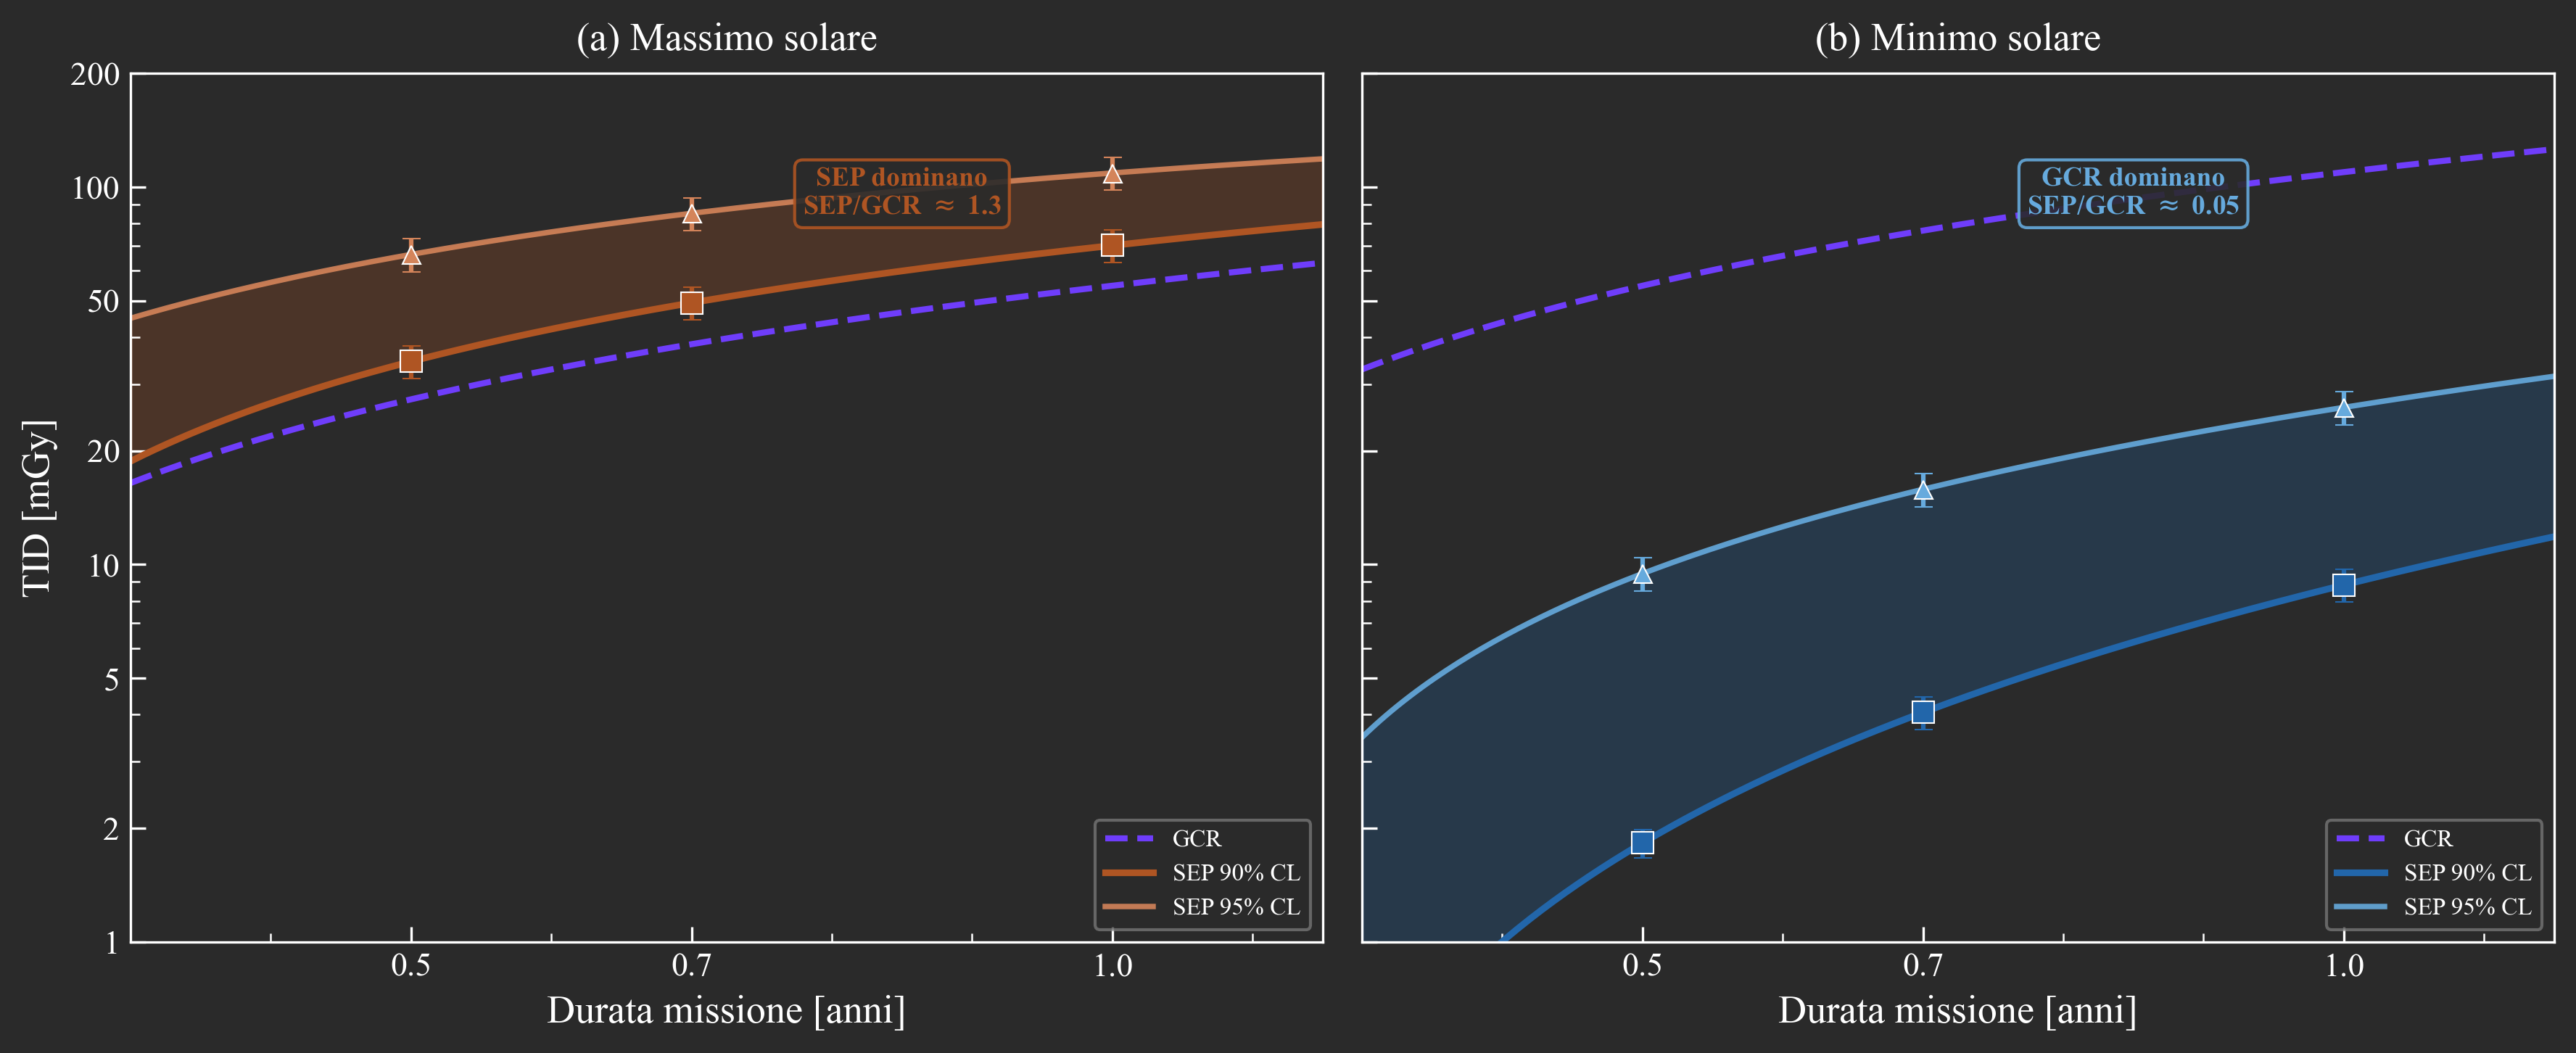

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, FixedLocator, NullFormatter
from scipy.interpolate import interp1d

# --- Thesis rcParams style ---
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'axes.grid': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.patch.set_facecolor('#2a2a2a')

# --- DATA from thesis (Table 4.1, spherical, 1 AU) ---
durations_data = np.array([0.5, 0.7, 1.0])

# SEP Solar Max
sep_max_90 = np.array([43.4, 62.1, 88.1])
sep_max_90_err = np.array([4.3, 6.2, 8.7])
sep_max_95 = np.array([83.4, 107.2, 137.1])
sep_max_95_err = np.array([8.3, 10.6, 13.6])

# SEP Solar Min
sep_min_90 = np.array([2.3, 5.1, 11.1])
sep_min_90_err = np.array([0.2, 0.5, 1.1])
sep_min_95 = np.array([11.9, 19.9, 32.8])
sep_min_95_err = np.array([1.2, 2.0, 3.3])

# SOLPENCO2 scaling
f_solpenco = 0.795

sep_max_90_sc = sep_max_90 * f_solpenco
sep_max_90_sc_err = sep_max_90_err * f_solpenco
sep_max_95_sc = sep_max_95 * f_solpenco
sep_max_95_sc_err = sep_max_95_err * f_solpenco

sep_min_90_sc = sep_min_90 * f_solpenco
sep_min_90_sc_err = sep_min_90_err * f_solpenco
sep_min_95_sc = sep_min_95 * f_solpenco
sep_min_95_sc_err = sep_min_95_err * f_solpenco

# GCR dose rates (Si)
gcr_rate_max = 0.15  # mGy/day solar max (low GCR)
gcr_rate_min = 0.30  # mGy/day solar min (high GCR)

# Smooth curves
durations_smooth = np.linspace(0.3, 1.15, 200)
days_smooth = durations_smooth * 365.25

gcr_max_dose = gcr_rate_max * days_smooth
gcr_min_dose = gcr_rate_min * days_smooth

# Interpolations — SOLPENCO2 scaled
s_max_90_sc = interp1d(durations_data, sep_max_90_sc, kind='quadratic', fill_value='extrapolate')(durations_smooth)
s_max_95_sc = interp1d(durations_data, sep_max_95_sc, kind='quadratic', fill_value='extrapolate')(durations_smooth)
s_min_90_sc = interp1d(durations_data, sep_min_90_sc, kind='quadratic', fill_value='extrapolate')(durations_smooth)
s_min_95_sc = interp1d(durations_data, sep_min_95_sc, kind='quadratic', fill_value='extrapolate')(durations_smooth)

# --- Colors ---
terracotta = '#AF5523'
terracotta_light = '#D4845A'
blue_dark = '#2266AA'
blue_light = '#66AADD'
gcr_color = "#6F3DFB"

# ============================================================
# PANEL (a): MASSIMO SOLARE
# ============================================================
ax1.set_facecolor('#2a2a2a')

ax1.plot(durations_smooth, gcr_max_dose, '--', color=gcr_color, linewidth=2.0, label='GCR')

ax1.fill_between(durations_smooth, s_max_90_sc, s_max_95_sc, alpha=0.25, color=terracotta)
ax1.plot(durations_smooth, s_max_90_sc, '-', color=terracotta, linewidth=2.2, label='SEP 90% CL')
ax1.plot(durations_smooth, s_max_95_sc, '-', color=terracotta_light, linewidth=1.8, alpha=0.9, label='SEP 95% CL')

ax1.errorbar(durations_data, sep_max_90_sc, yerr=sep_max_90_sc_err, fmt='s', color=terracotta,
             markersize=7, markeredgecolor='white', markeredgewidth=0.5, capsize=3, zorder=5)
ax1.errorbar(durations_data, sep_max_95_sc, yerr=sep_max_95_sc_err, fmt='^', color=terracotta_light,
             markersize=6, markeredgecolor='white', markeredgewidth=0.5, capsize=3, zorder=5)

ax1.annotate('SEP dominano\nSEP/GCR $\\approx$ 1.3', xy=(0.85, 85), fontsize=9, color=terracotta,
             fontweight='bold', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#2a2a2a', edgecolor=terracotta, alpha=0.9))



ax1.set_title('(a) Massimo solare', color='white', fontsize=13, pad=8)
ax1.set_xlabel('Durata missione [anni]', color='white')
ax1.set_ylabel('TID [mGy]', color='white')

legend1 = ax1.legend(loc='lower right', fontsize=8, framealpha=0.7,
                     facecolor='#2a2a2a', edgecolor='gray')
for text in legend1.get_texts():
    text.set_color('white')

# ============================================================
# PANEL (b): MINIMO SOLARE
# ============================================================
ax2.set_facecolor('#2a2a2a')

ax2.plot(durations_smooth, gcr_min_dose, '--', color=gcr_color, linewidth=2.0, label='GCR')

ax2.fill_between(durations_smooth, s_min_90_sc, s_min_95_sc, alpha=0.25, color=blue_dark)
ax2.plot(durations_smooth, s_min_90_sc, '-', color=blue_dark, linewidth=2.2, label='SEP 90% CL')
ax2.plot(durations_smooth, s_min_95_sc, '-', color=blue_light, linewidth=1.8, alpha=0.9, label='SEP 95% CL')

ax2.errorbar(durations_data, sep_min_90_sc, yerr=sep_min_90_sc_err, fmt='s', color=blue_dark,
             markersize=7, markeredgecolor='white', markeredgewidth=0.5, capsize=3, zorder=5)
ax2.errorbar(durations_data, sep_min_95_sc, yerr=sep_min_95_sc_err, fmt='^', color=blue_light,
             markersize=6, markeredgecolor='white', markeredgewidth=0.5, capsize=3, zorder=5)

ax2.annotate('GCR dominano\nSEP/GCR $\\approx$ 0.05', xy=(0.85, 85), fontsize=9, color=blue_light,
             fontweight='bold', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#2a2a2a', edgecolor=blue_light, alpha=0.9))


ax2.set_title('(b) Minimo solare', color='white', fontsize=13, pad=8)
ax2.set_xlabel('Durata missione [anni]', color='white')

legend2 = ax2.legend(loc='lower right', fontsize=8, framealpha=0.7,
                     facecolor='#2a2a2a', edgecolor='gray')
for text in legend2.get_texts():
    text.set_color('white')

# ============================================================
# SHARED FORMATTING
# ============================================================
for ax in [ax1, ax2]:
    ax.set_yscale('log')
    ax.set_xlim(0.3, 1.15)
    ax.set_ylim(1, 200)
    ax.set_xticks([0.5, 0.7, 1.0])
    ax.set_xticklabels(['0.5', '0.7', '1.0'])
    ax.tick_params(colors='white', which='both')
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_major_locator(FixedLocator([1, 2, 5, 10, 20, 50, 100, 200]))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:g}'))
    ax.yaxis.set_minor_formatter(NullFormatter())
    for spine in ax.spines.values():
        spine.set_color('white')



plt.tight_layout()
plt.savefig('sep_vs_gcr_2panel.png', dpi=300, facecolor='#2a2a2a',
            bbox_inches='tight', transparent=False)
plt.savefig('sep_vs_gcr_2panel.pdf', facecolor='#2a2a2a',
            bbox_inches='tight', transparent=False)
plt.show()

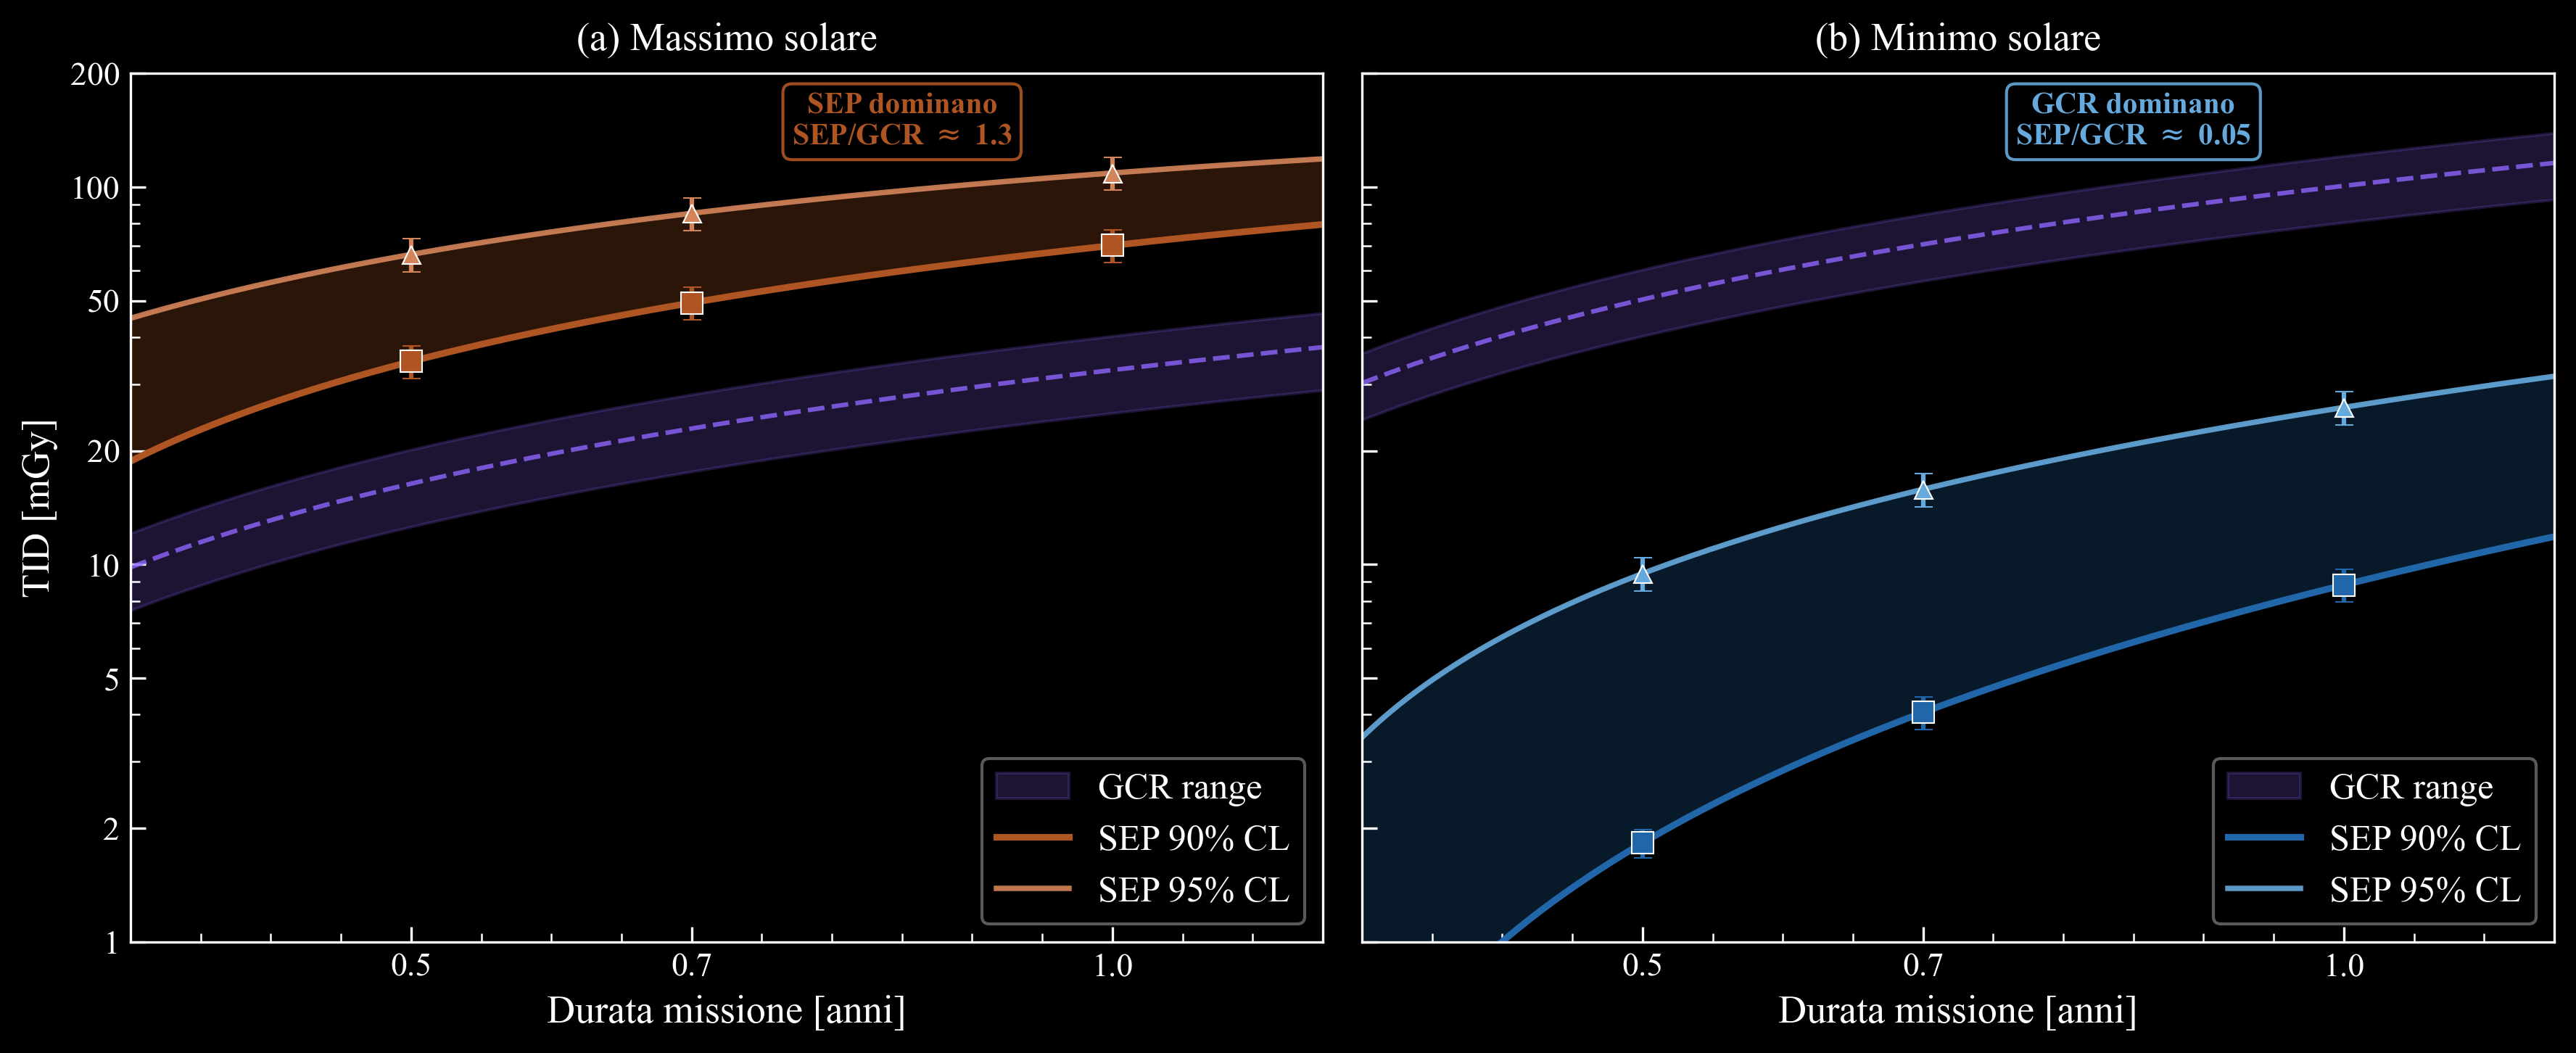

In [25]:
# --- GCR dose rate in Si (Simonsen et al. 2020) ---
gcr_rate_max_lo = 0.10 / 1.45   # = 0.069 mGy/day
gcr_rate_max_hi = 0.16 / 1.45   # = 0.110 mGy/day
gcr_rate_min_lo = 0.32 / 1.45   # = 0.221 mGy/day
gcr_rate_min_hi = 0.48 / 1.45   # = 0.331 mGy/day



import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, FixedLocator, NullFormatter
from scipy.interpolate import interp1d

plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'dejavuserif',
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 9,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'axes.grid': False,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig.patch.set_facecolor('#000000')

# --- DATA from thesis (Table 4.1, spherical, 1 AU) ---
durations_data = np.array([0.5, 0.7, 1.0])

sep_max_90 = np.array([43.4, 62.1, 88.1])
sep_max_90_err = np.array([4.3, 6.2, 8.7])
sep_max_95 = np.array([83.4, 107.2, 137.1])
sep_max_95_err = np.array([8.3, 10.6, 13.6])

sep_min_90 = np.array([2.3, 5.1, 11.1])
sep_min_90_err = np.array([0.2, 0.5, 1.1])
sep_min_95 = np.array([11.9, 19.9, 32.8])
sep_min_95_err = np.array([1.2, 2.0, 3.3])

f_solpenco = 0.795

sep_max_90_sc = sep_max_90 * f_solpenco
sep_max_90_sc_err = sep_max_90_err * f_solpenco
sep_max_95_sc = sep_max_95 * f_solpenco
sep_max_95_sc_err = sep_max_95_err * f_solpenco

sep_min_90_sc = sep_min_90 * f_solpenco
sep_min_90_sc_err = sep_min_90_err * f_solpenco
sep_min_95_sc = sep_min_95 * f_solpenco
sep_min_95_sc_err = sep_min_95_err * f_solpenco


durations_smooth = np.linspace(0.3, 1.15, 200)
days_smooth = durations_smooth * 365.25

gcr_max_lo = gcr_rate_max_lo * days_smooth
gcr_max_hi = gcr_rate_max_hi * days_smooth
gcr_min_lo = gcr_rate_min_lo * days_smooth
gcr_min_hi = gcr_rate_min_hi * days_smooth

# Interpolations — SOLPENCO2 scaled
s_max_90_sc = interp1d(durations_data, sep_max_90_sc, kind='quadratic', fill_value='extrapolate')(durations_smooth)
s_max_95_sc = interp1d(durations_data, sep_max_95_sc, kind='quadratic', fill_value='extrapolate')(durations_smooth)
s_min_90_sc = interp1d(durations_data, sep_min_90_sc, kind='quadratic', fill_value='extrapolate')(durations_smooth)
s_min_95_sc = interp1d(durations_data, sep_min_95_sc, kind='quadratic', fill_value='extrapolate')(durations_smooth)

# --- Colors ---
terracotta = '#AF5523'
terracotta_light = '#D4845A'
blue_dark = '#2266AA'
blue_light = '#66AADD'
gcr_color = "#8E65FE"

# ============================================================
# PANEL (a): MASSIMO SOLARE
# ============================================================
ax1.set_facecolor('#000000')

# GCR band
ax1.fill_between(durations_smooth, gcr_max_lo, gcr_max_hi, alpha=0.20, color=gcr_color, label='GCR range')
ax1.plot(durations_smooth, (gcr_max_lo + gcr_max_hi)/2, '--', color=gcr_color, linewidth=1.5, alpha=0.8)

# SEP
ax1.fill_between(durations_smooth, s_max_90_sc, s_max_95_sc, alpha=0.25, color=terracotta)
ax1.plot(durations_smooth, s_max_90_sc, '-', color=terracotta, linewidth=2.2, label='SEP 90% CL')
ax1.plot(durations_smooth, s_max_95_sc, '-', color=terracotta_light, linewidth=1.8, alpha=0.9, label='SEP 95% CL')

ax1.errorbar(durations_data, sep_max_90_sc, yerr=sep_max_90_sc_err, fmt='s', color=terracotta,
             markersize=7, markeredgecolor='white', markeredgewidth=0.5, capsize=3, zorder=5)
ax1.errorbar(durations_data, sep_max_95_sc, yerr=sep_max_95_sc_err, fmt='^', color=terracotta_light,
             markersize=6, markeredgecolor='white', markeredgewidth=0.5, capsize=3, zorder=5)

ax1.annotate('SEP dominano\nSEP/GCR $\\approx$ 1.3', xy=(0.85, 130), fontsize=10, color=terracotta,
             fontweight='bold', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#000000', edgecolor=terracotta, alpha=0.9))

ax1.set_title('(a) Massimo solare', color='white', fontsize=13, pad=8)
ax1.set_xlabel('Durata missione [anni]', color='white')
ax1.set_ylabel('TID [mGy]', color='white')

legend1 = ax1.legend(loc='lower right', fontsize=12, framealpha=0.7,
                     facecolor='#000000', edgecolor='gray')
for text in legend1.get_texts():
    text.set_color('white')

# ============================================================
# PANEL (b): MINIMO SOLARE
# ============================================================
ax2.set_facecolor('#000000')

# GCR band
ax2.fill_between(durations_smooth, gcr_min_lo, gcr_min_hi, alpha=0.20, color=gcr_color, label='GCR range')
ax2.plot(durations_smooth, (gcr_min_lo + gcr_min_hi)/2, '--', color=gcr_color, linewidth=1.5, alpha=0.8)

# SEP
ax2.fill_between(durations_smooth, s_min_90_sc, s_min_95_sc, alpha=0.25, color=blue_dark)
ax2.plot(durations_smooth, s_min_90_sc, '-', color=blue_dark, linewidth=2.2, label='SEP 90% CL')
ax2.plot(durations_smooth, s_min_95_sc, '-', color=blue_light, linewidth=1.8, alpha=0.9, label='SEP 95% CL')

ax2.errorbar(durations_data, sep_min_90_sc, yerr=sep_min_90_sc_err, fmt='s', color=blue_dark,
             markersize=7, markeredgecolor='white', markeredgewidth=0.5, capsize=3, zorder=5)
ax2.errorbar(durations_data, sep_min_95_sc, yerr=sep_min_95_sc_err, fmt='^', color=blue_light,
             markersize=6, markeredgecolor='white', markeredgewidth=0.5, capsize=3, zorder=5)

ax2.annotate('GCR dominano\nSEP/GCR $\\approx$ 0.05', xy=(0.85, 130), fontsize=10, color=blue_light,
             fontweight='bold', ha='center',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#000000', edgecolor=blue_light, alpha=0.9))

ax2.set_title('(b) Minimo solare', color='white', fontsize=13, pad=8)
ax2.set_xlabel('Durata missione [anni]', color='white')

legend2 = ax2.legend(loc='lower right', fontsize=12, framealpha=0.7,
                     facecolor='#000000', edgecolor='gray')
for text in legend2.get_texts():
    text.set_color('white')

# ============================================================
# SHARED FORMATTING
# ============================================================
for ax in [ax1, ax2]:
    ax.set_yscale('log')
    ax.set_xlim(0.3, 1.15)
    ax.set_ylim(1, 200)
    ax.set_xticks([0.5, 0.7, 1.0])
    ax.set_xticklabels(['0.5', '0.7', '1.0'])
    ax.tick_params(colors='white', which='both')
    # ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_major_locator(FixedLocator([1, 2, 5, 10, 20, 50, 100, 200]))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:g}'))
    ax.yaxis.set_minor_formatter(NullFormatter())
    for spine in ax.spines.values():
        spine.set_color('white')

plt.tight_layout()
plt.savefig('sep_vs_gcr_2panel1.png', dpi=300, facecolor='#000000',
            bbox_inches='tight', transparent=False)
plt.savefig('sep_vs_gcr_2panel1.pdf', facecolor='#000000',
            bbox_inches='tight', transparent=False)
plt.show()